### `Task` Train a KNN model on glass type dataset and find best n_neighnours.

Data Link: https://drive.google.com/file/d/17cbDNBmys04MJqQfrma3jd72VPMnxIq0/view?usp=share_link

In [51]:
# Your code goes here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,f1_score,accuracy_score
from sklearn.preprocessing import MinMaxScaler

In [4]:
df = pd.read_csv("Data\glass.csv")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
df["Type"].value_counts()

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

In [6]:
df.isna().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [7]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [8]:
x.shape

(214, 9)

In [9]:
y.shape

(214,)

In [56]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 20)

In [57]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [58]:
def best_knn(n):
    f1 = []
    n_list = []
    
    for item in range(1,n+1):
        clf = KNeighborsClassifier(n_neighbors = item)
        clf.fit(x_train,y_train)
        y_pred = clf.predict(x_test)
        f1.append(accuracy_score(y_test,y_pred))
        n_list.append(item)
    
    return f1,n_list
        

In [59]:
f1,n_list = best_knn(16)

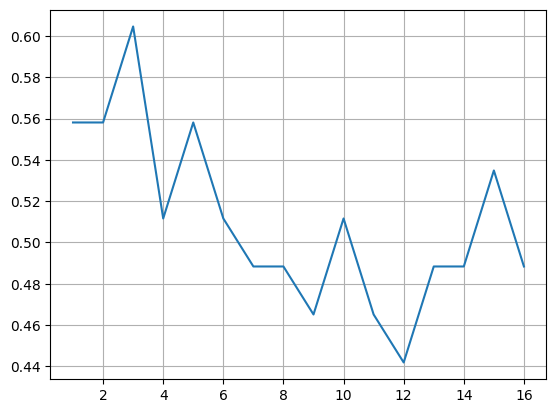

In [60]:
plt.plot(n_list,f1)
plt.grid(True)
plt.show()

In [22]:
from sklearn.metrics import accuracy_score,confusion_matrix
print("KNN accuracy score")
df1 = accuracy_score(y_test,y_pred)
print(df1)
print("*"*30)
print("KNN Confusion Matrix\n")
df2 = pd.DataFrame(confusion_matrix(y_test,y_pred),columns=list(range(0,6)))
print(df2)

KNN accuracy score
0.6511627906976745
******************************
KNN Confusion Matrix

   0  1  2  3  4  5
0  9  1  1  0  0  0
1  5  9  0  0  0  0
2  2  0  1  0  0  0
3  0  2  0  1  0  1
4  0  1  0  0  1  1
5  0  0  0  0  1  7


In [61]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.25      0.36      0.30        11
           2       0.38      0.31      0.34        16
           3       0.00      0.00      0.00         6
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         1
           7       0.44      0.57      0.50         7

    accuracy                           0.30        43
   macro avg       0.18      0.21      0.19        43
weighted avg       0.28      0.30      0.29        43

